In [1]:
import platform
import sklearn

print(platform.system())
if platform.system() =='Windows':
    sklearn.set_config(display='text')

Windows


In [2]:

import matplotlib.pyplot as plt

# OS에 따른 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')  # 윈도우: 맑은 고딕
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')    # 맥: 애플 고딕
else:
    plt.rc('font', family='NanumBarunGothic') # 리눅스

# 마이너스 기호 깨짐 방지
plt.rc('axes', unicode_minus=False)

dir(kmeans): ['__abstractmethods__', '__annotations__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__sklearn_clone__', '__sklearn_tags__', '__slots__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_check_mkl_vcomp', '_check_params_vs_input', '_check_test_data', '_doc_link_module', '_doc_link_template', '_doc_link_url_param_generator', '_get_class_level_metadata_request_values', '_get_doc_link', '_get_fitted_attr_html', '_get_metadata_request', '_get_param_names', '_get_params_html', '_html_repr', '_init_centroids', '_parameter_constraints', '_repr_html_inner', '_repr_mimebundle_', '_sklearn_auto_wrap_output_keys', '_transform', '_validate_center_shape', '_validate_params', '_warn_mkl_vcom

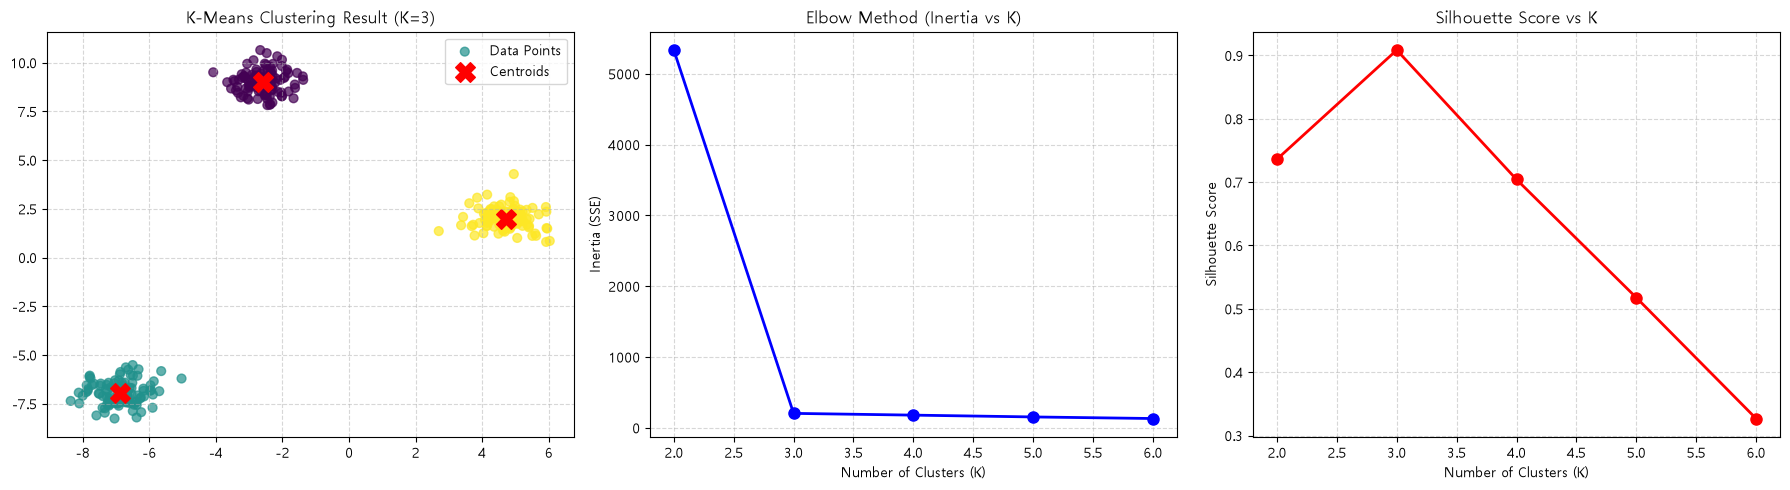

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
    silhouette_samples,
)

# 1. 가상 데이터셋 생성 (3개 군집, 2차원 공간)
X, y_true = make_blobs(
    n_samples=300, centers=3, cluster_std=0.60, random_state=42     # cluster_std=0.60:클러스터 표준편차
)

# 2. K-Means 모델 정의 및 학습 (K=3, K-Means++ 초기화)
kmeans = KMeans(n_clusters=3, init="k-means++", n_init=10, random_state=42) # KMeans 알고리즘 생성 
print(f'dir(kmeans): {dir(kmeans)}')

labels = kmeans.fit_predict(X)
# kmeans.fit(X, y)    # 지도학습에서 학습할때 방법

# 클러스터(군집)의 중심점(Centroid)를 알려준다.
# centroids:[[-2.58361866  9.03185632] [-6.88217395 -6.94243433] [ 4.70421356  1.99562444]]
centroids = kmeans.cluster_centers_     # 클러스터의 중심점 좌표
print(f'centroids:{centroids}')

# ==================================================
# 3. 단일 K(K=3)에 대한 평가 지표 계산
# ==================================================
inertia = kmeans.inertia_  # 군집 내 오차제곱합 (SSE), 최적의 K개수 구할 때 사용, 엘보우 기법의 좌표y축의 이너셔 값
print(f'intertia: {inertia}')   # intertia: 204.0694384047887

# 각 데이터 포인트에 대한 개별 실루엣 계수 확인
# sil_samp = silhouette_samples(X, labels)
# print(f'sil_samp:{sil_samp}')

sil_score = silhouette_score(X, labels)     # 실루엣 score, 2. 실루엣 계수 (Silhouette Score) : 0.9084 (1에 가까울수록 양호) -> 군집화가 잘된 것이다.

ch_score = calinski_harabasz_score(X, labels)   # 3. Calinski-Harabasz Index     : 14321.2470 (높을수록 양호)

db_score = davies_bouldin_score(X, labels)      # 4. Davies-Bouldin Index        : 0.1281 (0에 가까울수록 양호)

print("=== K-Means 군집화 평가 결과 (K=3) ===")
print(f"1. Inertia (군집 내 SSE)         : {inertia:.4f}")
print(f"2. 실루엣 계수 (Silhouette Score) : {sil_score:.4f} (1에 가까울수록 양호)")
print(f"3. Calinski-Harabasz Index     : {ch_score:.4f} (높을수록 양호)")
print(f"4. Davies-Bouldin Index        : {db_score:.4f} (0에 가까울수록 양호)")
print("-" * 45)

# ==================================================
# 4. 최적 K 탐색 (Elbow Method & Silhouette Analysis)
# ==================================================
inertias = []
sil_scores = []
K_range = range(2, 7)

for k in K_range:
  km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
  cluster_labels = km.fit_predict(X)

  inertias.append(km.inertia_)
  sil_scores.append(silhouette_score(X, cluster_labels))


# ==================================================
# 5. 시각화 (군집 결과 + 엘보우 그래프 + 실루엣 변화)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) K=3 군집화 산점도
axes[0].scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    s=40,
    cmap="viridis",
    alpha=0.7,
    label="Data Points",
)
axes[0].scatter(
    centroids[:, 0],
    centroids[:, 1],
    c="red",
    s=200,
    marker="X",
    label="Centroids",
)
axes[0].set_title("K-Means Clustering Result (K=3)", fontsize=12)
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)

# (2) Elbow Method (Inertia vs K)
axes[1].plot(K_range, inertias, "bo-", linewidth=2, markersize=8)
axes[1].set_title("Elbow Method (Inertia vs K)", fontsize=12)
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Inertia (SSE)")
axes[1].grid(True, linestyle="--", alpha=0.5)

# (3) Silhouette Score vs K
axes[2].plot(K_range, sil_scores, "ro-", linewidth=2, markersize=8)
axes[2].set_title("Silhouette Score vs K", fontsize=12)
axes[2].set_xlabel("Number of Clusters (K)")
axes[2].set_ylabel("Silhouette Score")
axes[2].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## K-Means 전처리 포함 전체 실습 코드
- 붓꽃(Iris) 데이터셋 붓꽃(Iris) 데이터셋을 활용하여 데이터 전처리(StandardScaler)부터 K-Means 모델 학습, 최적의 $K$ 선택(Elbow Method & Silhouette), 시각화 및 평가

--- 원본 데이터 상위 5개 항목 ---
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
--------------------------------------------------


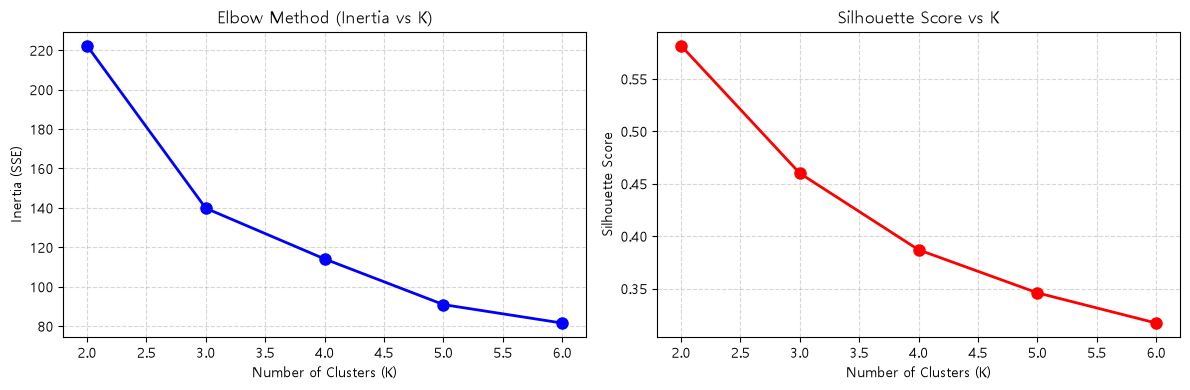

=== 최종 K-Means 평가 결과 (K=3) ===
1. Inertia (군집 내 SSE)         : 139.8205
2. 실루엣 계수 (Silhouette Score) : 0.4599 (1에 가까울수록 양호)
3. Calinski-Harabasz Index     : 241.9044 (높을수록 양호)
4. Davies-Bouldin Index        : 0.8336 (0에 가까울수록 양호)
--------------------------------------------------


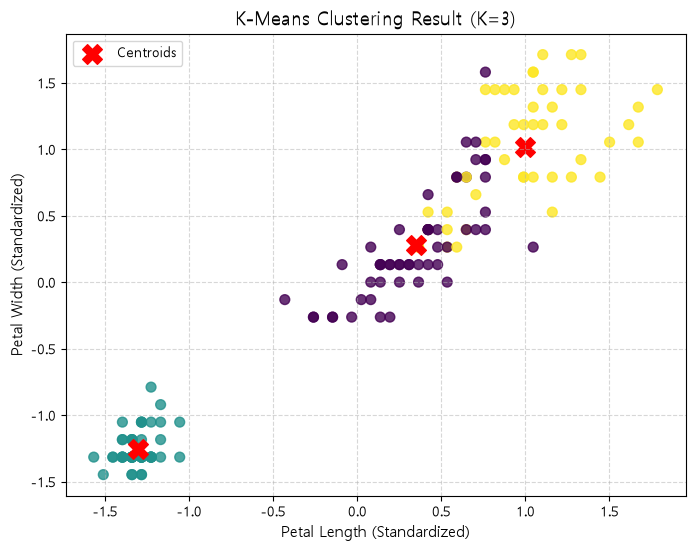

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler

# ==================================================
# 1. 데이터 로드 및 확인
# ==================================================
iris = load_iris()
X = iris.data
feature_names = iris.feature_names

# Pandas DataFrame으로 변환
df = pd.DataFrame(X, columns=feature_names)
print("--- 원본 데이터 상위 5개 항목 ---")
print(df.head())
print("-" * 50)

# ==================================================
# 2. 데이터 전처리 (StandardScaler)
# ==================================================
# 거리 기반 알고리즘 특성상 변수 간 스케일 차이가 크면 거리가 편향됩니다.
# 평균 0, 표준편차 1로 맞춰주는 표준화(Standardization) 작업 필수!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==================================================
# 3. 최적의 K(군집 수) 탐색 (Elbow Method & Silhouette Score)
# ==================================================
inertias = []
sil_scores = []
K_range = range(2, 7)

for k in K_range:
  kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
  labels = kmeans.fit_predict(X_scaled)

  inertias.append(kmeans.inertia_)
  sil_scores.append(silhouette_score(X_scaled, labels))

# 최적 K 탐색 그래프 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Elbow Method
axes[0].plot(K_range, inertias, "bo-", linewidth=2, markersize=8)
axes[0].set_title("Elbow Method (Inertia vs K)")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia (SSE)")
axes[0].grid(True, linestyle="--", alpha=0.5)

# Silhouette Score
axes[1].plot(K_range, sil_scores, "ro-", linewidth=2, markersize=8)
axes[1].set_title("Silhouette Score vs K")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# ==================================================
# 4. 최종 K-Means 모델 생성 및 학습 (K=3 선택)
# ==================================================
best_k = 3
final_kmeans = KMeans(
    n_clusters=best_k, init="k-means++", n_init=10, random_state=42
)
final_labels = final_kmeans.fit_predict(X_scaled)
centroids = final_kmeans.cluster_centers_

# 결과를 DataFrame에 추가
df["Cluster"] = final_labels

# ==================================================
# 5. 모델 평가 (Evaluation Metrics)
# ==================================================
sil = silhouette_score(X_scaled, final_labels)
ch = calinski_harabasz_score(X_scaled, final_labels)
db = davies_bouldin_score(X_scaled, final_labels)

print(f"=== 최종 K-Means 평가 결과 (K={best_k}) ===")
print(f"1. Inertia (군집 내 SSE)         : {final_kmeans.inertia_:.4f}")
print(f"2. 실루엣 계수 (Silhouette Score) : {sil:.4f} (1에 가까울수록 양호)")
print(f"3. Calinski-Harabasz Index     : {ch:.4f} (높을수록 양호)")
print(f"4. Davies-Bouldin Index        : {db:.4f} (0에 가까울수록 양호)")
print("-" * 50)

# ==================================================
# 6. 군집화 결과 시각화 (2개 주요 특성 기준)
# ==================================================
plt.figure(figsize=(8, 6))

# 꽃잎 길이(Petal Length)와 꽃잎 너비(Petal Width) 특성을 기준으로 산점도 생성
plt.scatter(
    X_scaled[:, 2],
    X_scaled[:, 3],
    c=final_labels,
    cmap="viridis",
    s=50,
    alpha=0.8,
)
plt.scatter(
    centroids[:, 2],
    centroids[:, 3],
    c="red",
    s=200,
    marker="X",
    label="Centroids",
)

plt.title(f"K-Means Clustering Result (K={best_k})", fontsize=14)
plt.xlabel("Petal Length (Standardized)", fontsize=11)
plt.ylabel("Petal Width (Standardized)", fontsize=11)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()